Clustering Comparison on Iris Dataset
-------------------------------------
K-Means          -> Silhouette: 0.480, ARI: 0.433
Spectral         -> Silhouette: 0.459, ARI: 0.646
Hierarchical     -> Silhouette: 0.447, ARI: 0.615


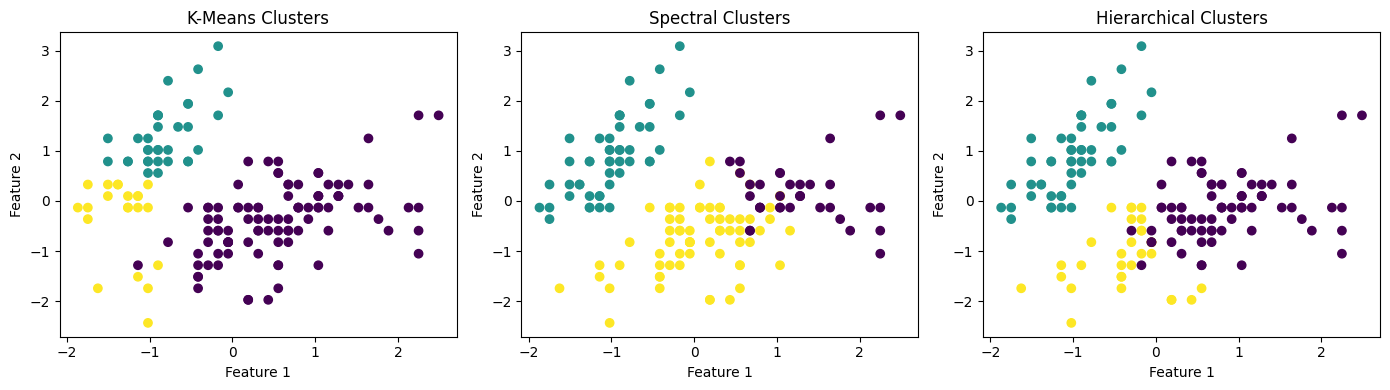

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# --------------------------
# 1) Load dataset
# --------------------------
data = load_iris()
X = data.data          # features
y_true = data.target   # true labels (just for comparison, NOT used in clustering)

# Optional: scale data (good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Number of clusters (we know iris has 3 classes)
k = 3

# --------------------------
# 2) K-Means Clustering
# --------------------------
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)

# --------------------------
# 3) Spectral Clustering
# --------------------------
spectral = SpectralClustering(
    n_clusters=k,
    affinity='nearest_neighbors',
    assign_labels='kmeans',
    random_state=42
)
spectral_labels = spectral.fit_predict(X_scaled)

spectral_sil = silhouette_score(X_scaled, spectral_labels)
spectral_ari = adjusted_rand_score(y_true, spectral_labels)

# --------------------------
# 4) Hierarchical (Agglomerative) Clustering
# --------------------------
hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

hier_sil = silhouette_score(X_scaled, hier_labels)
hier_ari = adjusted_rand_score(y_true, hier_labels)

# --------------------------
# 5) Print comparison
# --------------------------
print("Clustering Comparison on Iris Dataset")
print("-------------------------------------")
print(f"K-Means          -> Silhouette: {kmeans_sil:.3f}, ARI: {kmeans_ari:.3f}")
print(f"Spectral         -> Silhouette: {spectral_sil:.3f}, ARI: {spectral_ari:.3f}")
print(f"Hierarchical     -> Silhouette: {hier_sil:.3f}, ARI: {hier_ari:.3f}")

# --------------------------
# 6) Optional: Visualize clusters in 2D using first two features
# --------------------------
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1,3,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=spectral_labels)
plt.title("Spectral Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1,3,3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hier_labels)
plt.title("Hierarchical Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()
